In [ ]:
#Sushmita Shrestha
#2408996

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


For Classification Task:
1. Exploratory Data Analysis and Data Understanding:
1. Choosing a Dataset:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

data = pd.read_csv("/content/drive/MyDrive/datasets/Student Depression Dataset.csv")
data

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27,Surat,Student,5,0,5.75,5,0,5-6 hours,Unhealthy,Class 12,Yes,7,1.0,Yes,0
27897,140686,Male,27,Ludhiana,Student,2,0,9.40,3,0,Less than 5 hours,Healthy,MSc,No,0,3.0,Yes,0
27898,140689,Male,31,Faridabad,Student,3,0,6.61,4,0,5-6 hours,Unhealthy,MD,No,12,2.0,No,0
27899,140690,Female,18,Ludhiana,Student,5,0,6.88,2,0,Less than 5 hours,Healthy,Class 12,Yes,10,5.0,No,1


In [ ]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  int64  
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  int64  
 6   Work Pressure                          27901 non-null  int64  
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  int64  
 9   Job Satisfaction                       27901 non-null  int64  
 10  Sleep Duration                         27901 non-null  object 
 11  Di

(a) When and by whom was the dataset created?

=> The dataset was created by Shodolamu Opeyemi, a Data Scientist and Machine   
  Learning Engineer from Lagos, Nigeria. It was created 2 months ago.

(b) How did you access the dataset?

=>  I accessed the dataset from Kaggle.

(c) How does it align with the chosen UNSDG?

=> The dataset aligns with UNSDG 3 (Good Health and Well-being) by focusing on
 student depression, which supports efforts to improve mental health and well-being for all.

 (d) List all the attributes (columns) present in the dataset.

 => The attributes in the dataset:

1. id

2. Gender

3. Age

4. City

5. Profession

6. Academic Pressure

7. Work Pressure

8. CGPA

9. Study Satisfaction

10. Job Satisfaction

11. Sleep Duration

12. Dietary Habits

13. Degree

14. Suicidal Thoughts

15. Work/Study Hours

16. Financial Stress

17. Family History of Mental Illness

18. Depression

Identify potential questions that the dataset could help answer.


How do factors like age, gender, pressures, satisfaction, and habits influence depression levels?

=>The dataset can help analyze how factors like gender, age, academic and work pressures, CGPA, satisfaction levels, sleep, dietary habits, family history, financial stress, and work/study hours contribute to depression levels.

Assess the dataset’s suitability for analysis (e.g., data completeness, relevance, and quality).

=>
The dataset is suitable for analysis with complete records (except for a small missing value in 'Financial Stress'), relevant factors related to mental health, and consistent data types, making it of good quality for studying depression.

2. Conducting Exploratory Data Analysis (EDA):

• Understanding the characteristics of the data beforehand is crucial for building a model with
acceptable performance. Before proceeding to build, train, and test the model, write code to
inspect, preview, summarize, explore, and visualize your data. For example:

In [ ]:
# Explore unique values in categorical columns
categorical_columns = ['Gender', 'City', 'Profession', 'Degree']
for column in categorical_columns:
    print(f"\nUnique values in {column}:")
    print(data[column].unique())


Unique values in Gender:
['Male' 'Female']

Unique values in City:
['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' 'Less Delhi' 'City' '3'
 'Less than 5 Kalyan' 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh' 'Reyansh'
 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini' 'Nandini'
 'Khaziabad']

Unique values in Profession:
['Student' 'Civil Engineer' 'Architect' 'UX/UI Designer'
 'Digital Marketer' 'Content Writer' 'Educational Consultant' 'Teacher'
 'Manager' 'Chef' 'Doctor' 'Lawyer' 'Entrepreneur' 'Pharmacist']

Unique values in Degree:
['B.Pharm' 'BSc' 'BA' 'BCA' 'M.Tech' 'PhD' 'Class 12' 'B.Ed' 'LLB' 'BE'
 'M.Ed' 'MSc' 'BHM' 'M.Pharm' 'MCA' 'MA' 'B.Com' 'MD' 'MBA' 'MBBS' 'M.Com'
 'B.Arch' 'LLM' 'B.Tech'

In [ ]:
#Remove duplicates (if any)
data = data.drop_duplicates()

# Check for missing values
print("Missing Values per columns: ")
data.isnull().sum()

Missing Values per columns: 


,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


In [ ]:
data['Financial Stress'].fillna(data['Financial Stress'].mean(), inplace=True)

<ipython-input-6-4ca79576a1f1>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Financial Stress'].fillna(data['Financial Stress'].mean(), inplace=True)


In [ ]:

# Check unique values for verification
print("Unique values before encoding:")
print("Family History of Mental Illness:", data['Family History of Mental Illness'].unique())
print("Have you ever had suicidal thoughts?:", data['Have you ever had suicidal thoughts ?'].unique())

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Label encode the binary features
binary_features = ['Family History of Mental Illness', 'Have you ever had suicidal thoughts ?']

for feature in binary_features:
    data[f'{feature} Encoded'] = label_encoder.fit_transform(data[feature])

# Display the encoded columns
print(data[[f'{feature} Encoded' for feature in binary_features]].head())


Unique values before encoding:
Family History of Mental Illness: ['No' 'Yes']
Have you ever had suicidal thoughts?: ['Yes' 'No']
   Family History of Mental Illness Encoded  \
0                                         0   
1                                         1   
2                                         1   
3                                         1   
4                                         0   

   Have you ever had suicidal thoughts ? Encoded  
0                                              1  
1                                              0  
2                                              0  
3                                              1  
4                                              1  


In [ ]:
data


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Family History of Mental Illness Encoded,Have you ever had suicidal thoughts ? Encoded
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1,0,1
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0,1,0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0,1,0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1,1,1
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27,Surat,Student,5,0,5.75,5,0,5-6 hours,Unhealthy,Class 12,Yes,7,1.0,Yes,0,1,1
27897,140686,Male,27,Ludhiana,Student,2,0,9.40,3,0,Less than 5 hours,Healthy,MSc,No,0,3.0,Yes,0,1,0
27898,140689,Male,31,Faridabad,Student,3,0,6.61,4,0,5-6 hours,Unhealthy,MD,No,12,2.0,No,0,0,0
27899,140690,Female,18,Ludhiana,Student,5,0,6.88,2,0,Less than 5 hours,Healthy,Class 12,Yes,10,5.0,No,1,0,1


In [ ]:
# Check unique values in Gender
print("Unique Gender values before encoding:", data['Gender'].unique())

# Label Encoding Gender
label_encoder_gender = LabelEncoder()
data['Gender_Encoded'] = label_encoder_gender.fit_transform(data['Gender'])

print("Unique Gender values after encoding:", data['Gender_Encoded'].unique())
print(data[['Gender', 'Gender_Encoded']].head())


Unique Gender values before encoding: ['Male' 'Female']
Unique Gender values after encoding: [1 0]
   Gender  Gender_Encoded
0    Male               1
1  Female               0
2    Male               1
3  Female               0
4  Female               0


In [ ]:
# 3. Ensure correct data types (Example: 'Age' as int, 'CGPA' as float)
data['Age'] = data['Age'].astype(int)
data['CGPA'] = data['CGPA'].astype(float)

# 4. Generate summary statistics
summary_stats = data.describe()
summary_stats

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression,Family History of Mental Illness Encoded,Have you ever had suicidal thoughts ? Encoded,Gender_Encoded
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499,0.483961,0.632809,0.557220
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437269,0.492645,0.499752,0.482048,0.496724
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000,0.000000,1.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000,1.000000,1.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:

# 5. Check for data inconsistencies
# For example, ensure 'Age' is within a reasonable range
data = data[data['Age'] >= 18]
data = data[data['Age'] <= 100]

In [ ]:
# Drop unnecessary columns
data = data.drop(columns=['Diet_Others', 'City', 'Profession','Job Satisfaction'], errors='ignore')

# Verify by checking the first few rows
print(data.head())


   id  Gender  Age  Academic Pressure  Work Pressure  CGPA  \
0   2    Male   33                  5              0  8.97   
1   8  Female   24                  2              0  5.90   
2  26    Male   31                  3              0  7.03   
3  30  Female   28                  3              0  5.59   
4  32  Female   25                  4              0  8.13   

   Study Satisfaction     Sleep Duration Dietary Habits   Degree  \
0                   2          5-6 hours        Healthy  B.Pharm   
1                   5          5-6 hours       Moderate      BSc   
2                   5  Less than 5 hours        Healthy       BA   
3                   2          7-8 hours       Moderate      BCA   
4                   3          5-6 hours       Moderate   M.Tech   

  Have you ever had suicidal thoughts ?  Work/Study Hours  Financial Stress  \
0                                   Yes                 3               1.0   
1                                    No                 3   

In [ ]:
# Ensure column selection uses a list, not a tuple
X = data[['id', 'Age', 'CGPA', 'Work Pressure', 'Financial Stress',
          'Academic Pressure', 'Study Satisfaction', 'Work/Study Hours',
          'Financial Stress', 'Have you ever had suicidal thoughts ? Encoded',
          'Family History of Mental Illness Encoded', 'Gender_Encoded']]

y = data['Depression']


In [ ]:
# 3. Ensure correct data types (Example: 'Age' as int, 'CGPA' as float)
data['Age'] = data['Age'].astype(int)
data['CGPA'] = data['CGPA'].astype(float)

In [ ]:

# 6. Final cleaned dataset
cleaned_data = data
cleaned_data

,id,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Family History of Mental Illness Encoded,Have you ever had suicidal thoughts ? Encoded,Gender_Encoded
0,2,Male,33,5,0,8.97,2,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1,0,1,1
1,8,Female,24,2,0,5.90,5,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0,1,0,0
2,26,Male,31,3,0,7.03,5,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0,1,0,1
3,30,Female,28,3,0,5.59,2,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1,1,1,0
4,32,Female,25,4,0,8.13,3,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27,5,0,5.75,5,5-6 hours,Unhealthy,Class 12,Yes,7,1.0,Yes,0,1,1,0
27897,140686,Male,27,2,0,9.40,3,Less than 5 hours,Healthy,MSc,No,0,3.0,Yes,0,1,0,1
27898,140689,Male,31,3,0,6.61,4,5-6 hours,Unhealthy,MD,No,12,2.0,No,0,0,0,1
27899,140690,Female,18,5,0,6.88,2,Less than 5 hours,Healthy,Class 12,Yes,10,5.0,No,1,0,1,0


In [ ]:
# Print summary statistics
print("Summary Statistics:")
print(summary_stats)

Summary Statistics:
                  id           Age  Academic Pressure  Work Pressure  \
count   27901.000000  27901.000000       27901.000000   27901.000000   
mean    70442.149421     25.822300           3.141214       0.000430   
std     40641.175216      4.905687           1.381465       0.043992   
min         2.000000     18.000000           0.000000       0.000000   
25%     35039.000000     21.000000           2.000000       0.000000   
50%     70684.000000     25.000000           3.000000       0.000000   
75%    105818.000000     30.000000           4.000000       0.000000   
max    140699.000000     59.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
count  27901.000000        27901.000000      27901.000000      27901.000000   
mean       7.656104            2.943837          0.000681          7.156984   
std        1.470707            1.361148          0.044394          3.707642   
min        0.00

<ipython-input-21-d8414c079dbc>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Depression", data=data, palette="coolwarm")


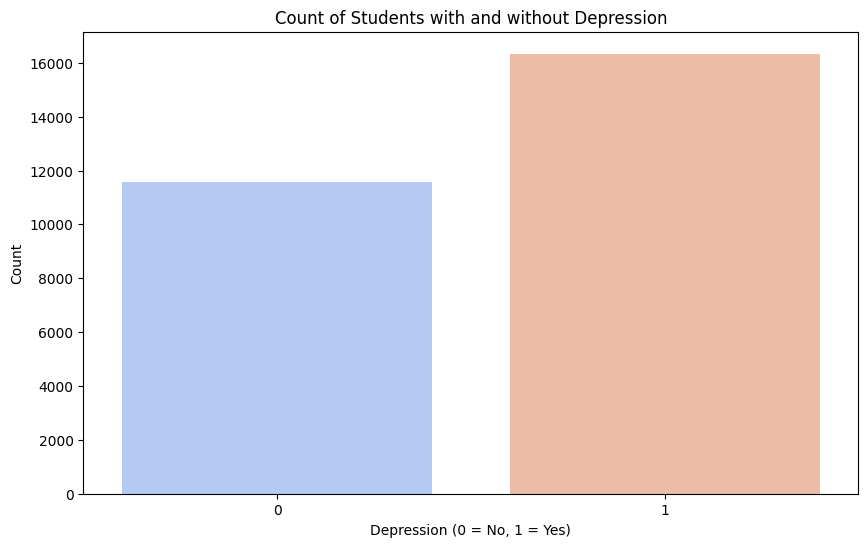

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Depression", data=data, palette="coolwarm")
plt.title("Count of Students with and without Depression")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

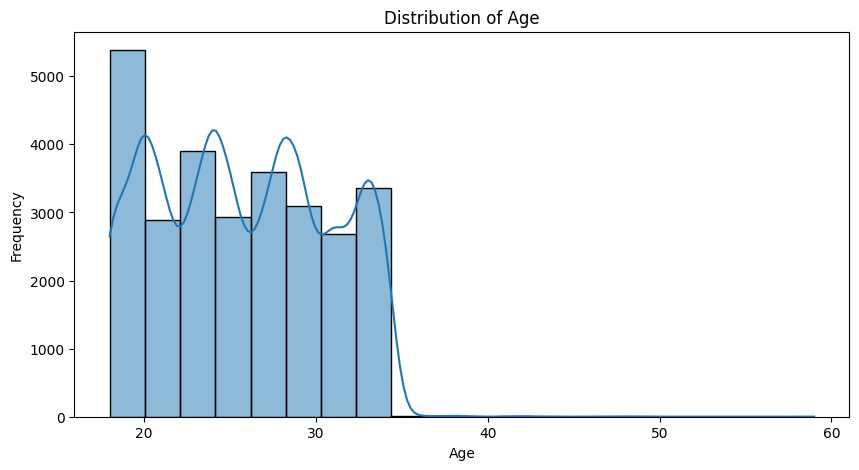

In [ ]:
# Plot distribution of Age
plt.figure(figsize=(10, 5))
sns.histplot(data['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Insights: This plot shows the distribution of ages and can help you see if the dataset is evenly distributed across different age groups.

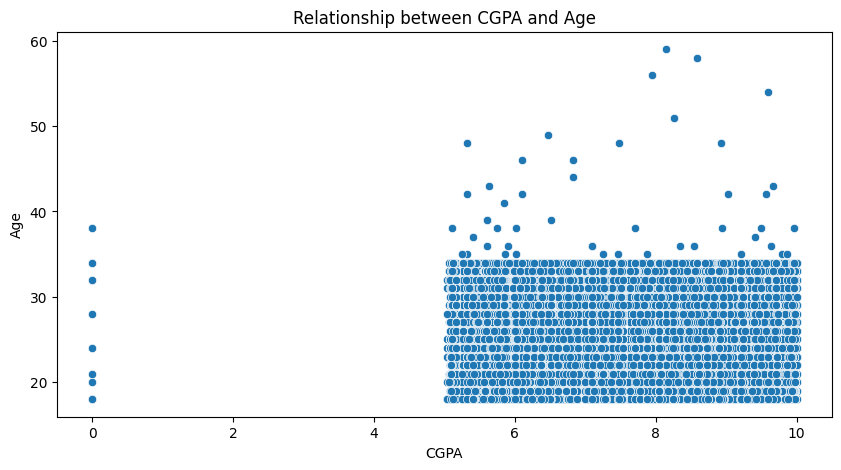

In [ ]:
# Plot correlation between 'CGPA' and 'Age'
plt.figure(figsize=(10, 5))
sns.scatterplot(x='CGPA', y='Age', data=data)
plt.title('Relationship between CGPA and Age')
plt.xlabel('CGPA')
plt.ylabel('Age')
plt.show()

Insights: This scatter plot shows the relationship between CGPA and Age, which might reveal if there's any trend or correlation.

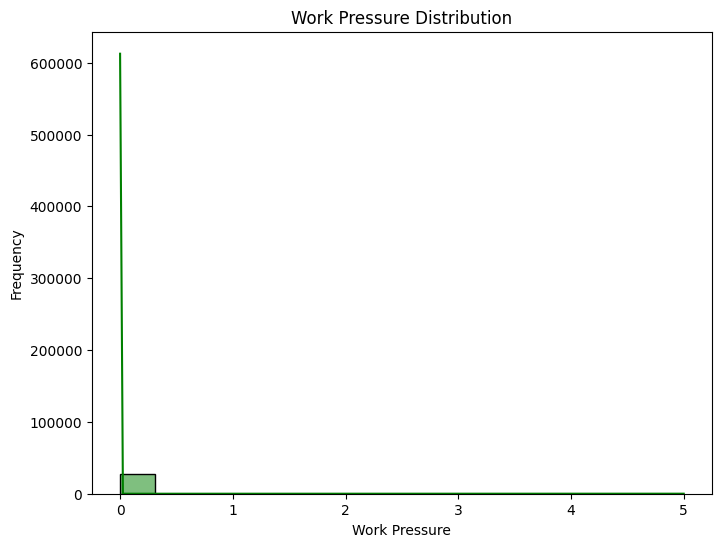

In [ ]:
# Plot distribution of 'Work Pressure'
plt.figure(figsize=(8, 6))
sns.histplot(data['Work Pressure'], kde=True, color='green')
plt.title('Work Pressure Distribution')
plt.xlabel('Work Pressure')
plt.ylabel('Frequency')
plt.show()


Insights: This histogram will help us understand the spread of work pressure values in the dataset, highlighting if most people experience low or high work pressure.

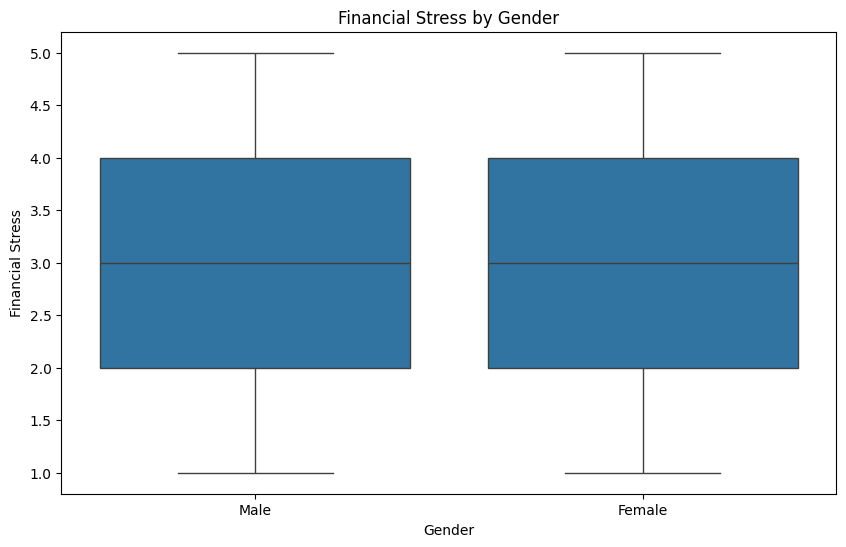

In [ ]:
# Boxplot for 'Financial Stress' by Gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Financial Stress', data=data)
plt.title('Financial Stress by Gender')
plt.xlabel('Gender')
plt.ylabel('Financial Stress')
plt.show()

Insights: The boxplot shows how financial stress varies by gender. We can look for outliers and see if one gender experiences more financial stress than the other.

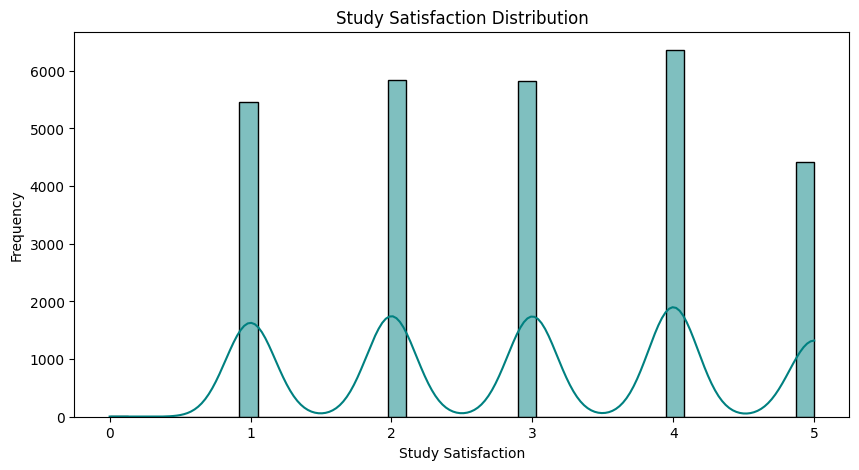

In [ ]:
# Plot the distribution of 'Study Satisfaction'
plt.figure(figsize=(10, 5))
sns.histplot(data['Study Satisfaction'], kde=True, color='teal')
plt.title('Study Satisfaction Distribution')
plt.xlabel('Study Satisfaction')
plt.ylabel('Frequency')
plt.show()

Insights: This bar chart shows the frequency of different levels of study satisfaction in the dataset. It helps identify the general sentiment towards study satisfaction.

**2. Build a Model from Scratch:**

In [ ]:
# Select features and target variable
X = data[['Age', 'CGPA', 'Work Pressure', 'Financial Stress','Academic Pressure','Study Satisfaction', 'Work/Study Hours']]  # Example feature columns
y = data['Depression']  # Target variable (binary classification: 1 for depressed, 0 for not)

X, y

(       Age  CGPA  Work Pressure  Financial Stress  Academic Pressure  \
 0       33  8.97              0               1.0                  5   
 1       24  5.90              0               2.0                  2   
 2       31  7.03              0               1.0                  3   
 3       28  5.59              0               5.0                  3   
 4       25  8.13              0               1.0                  4   
 ...    ...   ...            ...               ...                ...   
 27896   27  5.75              0               1.0                  5   
 27897   27  9.40              0               3.0                  2   
 27898   31  6.61              0               2.0                  3   
 27899   18  6.88              0               5.0                  5   
 27900   27  9.24              0               3.0                  4   
 
        Study Satisfaction  Work/Study Hours  
 0                       2                 3  
 1                       5  

In [ ]:

# Standardize features (important for gradient descent convergence)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled



array([[ 1.46316463,  0.89339281, -0.00977677, ...,  1.34554256,
        -0.69342502, -1.12121344],
       [-0.37147351, -1.19407552, -0.00977677, ..., -0.82610429,
         1.51063645, -1.12121344],
       [ 1.05546726, -0.42572399, -0.00977677, ..., -0.10222201,
         1.51063645,  0.49709475],
       ...,
       [ 1.05546726, -0.71130597, -0.00977677, ..., -0.10222201,
         0.77594929,  1.30624884],
       [-1.5945656 , -0.52771755, -0.00977677, ...,  1.34554256,
        -0.69342502,  0.76681278],
       [ 0.24007254,  1.07698123, -0.00977677, ...,  0.62166028,
        -1.42811218, -1.39093147]])

In [ ]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

(array([[ 0.44392122,  0.43102198, -0.00977677, ..., -0.82610429,
          1.51063645, -0.85149541],
        [ 1.46316463,  0.94778938, -0.00977677, ...,  0.62166028,
          0.77594929,  1.30624884],
        [ 1.46316463,  0.28823098, -0.00977677, ...,  0.62166028,
          0.77594929,  1.30624884],
        ...,
        [-1.5945656 , -0.87449568, -0.00977677, ...,  1.34554256,
          0.04126213, -0.31205934],
        [-1.5945656 , -0.3033317 , -0.00977677, ..., -0.10222201,
          0.77594929, -1.93036753],
        [ 1.66701331, -0.01095015, -0.00977677, ..., -0.10222201,
          0.77594929, -0.58177738]]),
 array([[ 0.6477699 ,  0.59421168, -0.00977677, ..., -0.82610429,
          0.04126213,  0.76681278],
        [ 0.44392122, -1.41846137, -0.00977677, ..., -0.82610429,
          1.51063645, -1.12121344],
        [ 1.66701331, -1.72444207, -0.00977677, ..., -0.10222201,
          0.77594929, -0.85149541],
        ...,
        [-0.16762483,  1.51895336, -0.00977677, ...,  

In [ ]:
# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#Cost function Binarty Cross-Entropy loss
def compute_cost(A, Y):
  m = Y.shape[1]
  cost = (-1 / m) * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
  return cost

# Gradient_descent(X, Y, W, b, learning_rates = 0.01, epochs = 10000):
def Gradient_descent(X, Y, W, b, learning_rates = 0.01, epochs= 1000):
  m = X.shape[0]
  for i in range (epochs):
    #Forward propagation
    Z = np.dot(X, W) + b
    A = sigmoid(Z)

    # Compute cost
    cost = compute_cost(A, Y)

    # Backpropagation
    dZ = A - Y
    dW = (1 / m) * np.dot(X.T, dZ)
    db = (1 / m) * np.sum(dZ)

    # Update weights and bias
    W = W - learning_rates * dW
    b = b - learning_rates * db

    # Print cost every 100 epochs
    if i % 100 == 0:
        print(f"Epoch {i}, Cost: {cost}")
  return w, b

#Initialize weights and bias
w = np.zeros((X_train.shape[1], 1))
b = 0

#Train the model
w, b = Gradient_descent(X_train, y_train.values.reshape(-1, 1), w, b, learning_rates=0.01, epochs=1000)


Epoch 0, Cost: 15471.045070097978
Epoch 100, Cost: 13404.811415789125
Epoch 200, Cost: 12274.486405312462
Epoch 300, Cost: 11611.399662116055
Epoch 400, Cost: 11196.183478563595
Epoch 500, Cost: 10922.2257902952
Epoch 600, Cost: 10733.969482989614
Epoch 700, Cost: 10600.43255366995
Epoch 800, Cost: 10503.300562893139
Epoch 900, Cost: 10431.208354412589


In [ ]:
#Make prediction using trained weights
def predict(X, W, b):
    Z = np.dot(X, W) + b
    A = sigmoid(Z)
    predictions = (A >= 0.5).astype(int)
    return predictions

# Evaluate the model on train andmd test sets
y_train_pred = predict(X_train, w, b)
y_test_pred = predict(X_test, w, b)




In [ ]:

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Test st metrices
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Print evaluating metrics
print(f"Accuracy: {train_accuracy}")
print(f"Precision: {train_precision}")
print(f"Recall: {train_recall}")
print(f"F1 Score: {train_f1}")


Accuracy: 0.5868279569892473
Precision: 0.5868279569892473
Recall: 1.0
F1 Score: 0.7396239200406572


In [ ]:

print(f"Accuracy: {test_accuracy}")
print(f"Precision: {test_precision}")
print(f"Recall: {test_recall}")
print(f"F1 Score: {test_f1}")

Accuracy: 0.5801827629457087
Precision: 0.5801827629457087
Recall: 1.0
F1 Score: 0.7343236194579884


**3. Build a Primary Model [5]:**

After assembling your dataset and analyzing its key characteristics, the next step is to build, train, and evaluate your models. Follow the steps below to complete this task:

1. Split the dataset into training and testing sets.

2. Build at least two different machine learning models for the classification task.

3. Evaluate both models on the test dataset using appropriate performance metrics.

4. Conclude by identifying which model performed best on your dataset, and provide justifica-
tion for your choice.

**1. Split the dataset into training and testing sets.**

In [ ]:

X_train, X_test, y_train, y_test


(array([[ 0.44392122,  0.43102198, -0.00977677, ..., -0.82610429,
          1.51063645, -0.85149541],
        [ 1.46316463,  0.94778938, -0.00977677, ...,  0.62166028,
          0.77594929,  1.30624884],
        [ 1.46316463,  0.28823098, -0.00977677, ...,  0.62166028,
          0.77594929,  1.30624884],
        ...,
        [-1.5945656 , -0.87449568, -0.00977677, ...,  1.34554256,
          0.04126213, -0.31205934],
        [-1.5945656 , -0.3033317 , -0.00977677, ..., -0.10222201,
          0.77594929, -1.93036753],
        [ 1.66701331, -0.01095015, -0.00977677, ..., -0.10222201,
          0.77594929, -0.58177738]]),
 array([[ 0.6477699 ,  0.59421168, -0.00977677, ..., -0.82610429,
          0.04126213,  0.76681278],
        [ 0.44392122, -1.41846137, -0.00977677, ..., -0.82610429,
          1.51063645, -1.12121344],
        [ 1.66701331, -1.72444207, -0.00977677, ..., -0.10222201,
          0.77594929, -0.85149541],
        ...,
        [-0.16762483,  1.51895336, -0.00977677, ...,  

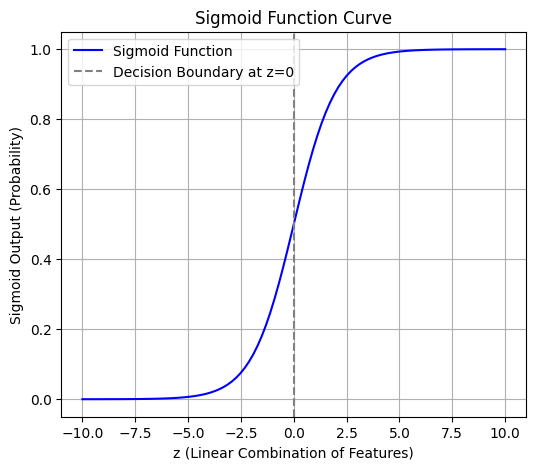

In [ ]:
z = np.linspace(-10, 10, 100)
sigmoid_values = 1 / (1 + np.exp(-z))

# Plot the sigmoid function
plt.figure(figsize=(6, 5))
plt.plot(z, sigmoid_values, label="Sigmoid Function", color='blue')
plt.axvline(0, color='gray', linestyle='--', label="Decision Boundary at z=0")
plt.xlabel("z (Linear Combination of Features)")
plt.ylabel("Sigmoid Output (Probability)")
plt.title("Sigmoid Function Curve")
plt.legend()
plt.grid()
plt.show()

**2. Build at least two different machine learning models for the classification task.**


=> Train and evaluate two models using:

1. Logistic Regression

2. Random Forest Classifier

=>  Logistic Regression is a simple and interpretable model, useful for baseline classification.

=> Random Forest Classifier is a more complex ensemble method that often provides better performance by capturing non-linear relationships.





**Model 1: Logistic Regression**

In [ ]:
# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predictions using Logistic Regression
y_train_pred_lr = log_reg.predict(X_train)
y_test_pred_lr = log_reg.predict(X_test)

# Evaluation for Logistic Regression
print("Logistic Regression - Train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Logistic Regression - Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
#print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_lr))
#print("Classification Report:\n", classification_report(y_test, y_test_pred_lr))


Logistic Regression - Train Accuracy: 0.7881720430107527
Logistic Regression - Test Accuracy: 0.7864182046228274


In [ ]:
# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions using Random Forest
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation for Random Forest
print("Random Forest - Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Random Forest - Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
#print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_rf))
#print("Classification Report:\n", classification_report(y_test, y_test_pred_rf))


Random Forest - Train Accuracy: 0.8788082437275986
Random Forest - Test Accuracy: 0.7788926715642358


**3. Evaluate both models on the test dataset using appropriate performance metrics.**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary')
    recall = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')

    print(f"{model_name} Performance Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 40)

# Predictions using Logistic Regression
y_test_pred_lr = log_reg.predict(X_test)

# Evaluate Logistic Regression and Random Forest
evaluate_model(y_test, y_test_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")


Logistic Regression Performance Metrics:
Accuracy: 0.7864
Precision: 0.8011
Recall: 0.8406
F1 Score: 0.8204
----------------------------------------
Random Forest Performance Metrics:
Accuracy: 0.7624
Precision: 0.7854
Recall: 0.8125
F1 Score: 0.7987
----------------------------------------


**4. Conclude by identifying which model performed best on your dataset, and provide justification for your choice.**

In [ ]:
from sklearn.metrics import f1_score

# Calculate F1 Scores
f1_rf = f1_score(y_test, y_pred_rf)
f1_lr = f1_score(y_test, y_test_pred_lr)

# Model comparison based on F1 score
if f1_rf > f1_lr:
    print("The Random Forest model performed better due to a higher F1 score and better generalization.")
else:
    print("The Logistic Regression model performed better due to higher overall metrics and efficiency.")


The Logistic Regression model performed better due to higher overall metrics and efficiency.


**Hyperparameter Optimization with Cross-Validation**

Optimizing the hyperparameters for both Random Forest and KNN using GridSearchCV and RandomizedSearchCV.

**Hyper-parameter Optimization with Cross-Validation**

In [ ]:

# Assuming X_selected is the result of your feature selection process
# Feature Selection using SelectKBest
selector = SelectKBest(score_func=f_classif, k=10)  # Selecting top 10 features
X_selected = selector.fit_transform(X, y) # Creating X_selected variable
selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

X_train_final, X_test_final, _, _ = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# Define and train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,  # Number of trees in the forest
    max_depth=12,      # Maximum depth of the trees
    random_state=42
)
rf_model.fit(X_train_final, y_train)

# Predictions
y_test_pred_rf = rf_model.predict(X_test_final)

# Evaluation Metrics
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_r2_score = r2_score(y_test, y_test_pred_rf)

print("\nRandom Forest Regression Model Performance:")
print(f"Test MAE: {rf_test_mae:.4f}, Test RMSE: {rf_test_rmse:.4f}, R2 Score: {rf_r2_score:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=10 is greater than n_features=7. All the features will be returned.
  warnings.warn(


Selected Features: Index(['Age', 'CGPA', 'Work Pressure', 'Financial Stress', 'Academic Pressure',
       'Study Satisfaction', 'Work/Study Hours'],
      dtype='object')

Random Forest Regression Model Performance:
Test MAE: 0.3009, Test RMSE: 0.3983, R2 Score: 0.3486


In [ ]:
# Hyperparameter tuning for Logistic Regression
log_reg = LogisticRegression()
param_grid_lr = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)
best_log_reg = grid_search_lr.best_estimator_

In [ ]:
# Hyperparameter tuning for Random Forest
rf_model = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_

In [ ]:
# Train and evaluate Logistic Regression
y_test_pred_lr = best_log_reg.predict(X_test)
print("Best Logistic Regression Parameters:", grid_search_lr.best_params_)
print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_test_pred_lr))

# Train and evaluate Random Forest
y_test_pred_rf = best_rf.predict(X_test)
print("Best Random Forest Parameters:", grid_search_rf.best_params_)
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_rf))
print("Classification Report:\n",  classification_report(y_test, y_test_pred_rf))

Best Logistic Regression Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Logistic Regression Test Accuracy: 0.7864182046228274
Confusion Matrix:
 [[1661  682]
 [ 510 2728]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74      2343
           1       0.80      0.84      0.82      3238

    accuracy                           0.79      5581
   macro avg       0.78      0.78      0.78      5581
weighted avg       0.79      0.79      0.79      5581

Best Random Forest Parameters: {'max_depth': 10, 'n_estimators': 100}
Random Forest Test Accuracy: 0.7781759541300842
Confusion Matrix:
 [[1613  730]
 [ 508 2730]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.69      0.72      2343
           1       0.79      0.84      0.82      3238

    accuracy                           0.78      5581
   macro avg       0.77      0.77      0.77      5581
weighted avg       0.

**5. Feature Selection**

 Using Recursive Feature Elimination (RFE) to select the most important features.


In [ ]:
#Feature Selection using SelectKBest
selector = SelectKBest(score_func=f_classif, k=10)  # Selecting top 10 features
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['Age', 'CGPA', 'Work Pressure', 'Financial Stress', 'Academic Pressure',
       'Study Satisfaction', 'Work/Study Hours'],
      dtype='object')


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=10 is greater than n_features=7. All the features will be returned.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=10 is greater than n_features=7. All the features will be returned.
  warnings.warn(


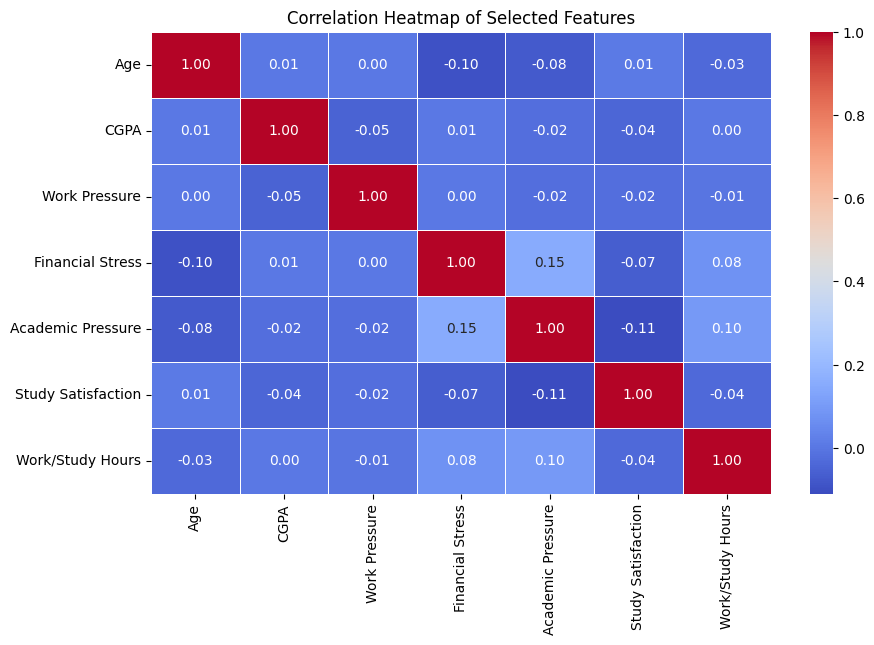

In [ ]:
# Feature Selection using SelectKBest
selector = SelectKBest(score_func=f_classif, k=10)  # Selecting top 10 features
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

# Create correlation matrix for selected features
selected_corr_matrix = data[selected_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(selected_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Selected Features")
plt.show()

**Final Model**

In [ ]:
# Final Model Training and Evaluation

# Train and evaluate Logistic Regression with best hyperparameters and selected features
y_test_pred_lr = best_log_reg.predict(X_test)
print("Best Logistic Regression Parameters:", grid_search_lr.best_params_)
print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_test_pred_lr))

y_test_pred_rf = best_rf.predict(X_test)
print("Best Random Forest Parameters:", grid_search_rf.best_params_)
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_rf))
print("Classification Report:\n",  classification_report(y_test, y_test_pred_rf))

# Compare and Conclude
if accuracy_score(y_test, y_test_pred_lr) > accuracy_score(y_test, y_test_pred_rf):
    print("Final Model: Logistic Regression performed better.")
else:
    print("Final Model: Random Forest performed better.")


Best Logistic Regression Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Logistic Regression Test Accuracy: 0.7864182046228274
Confusion Matrix:
 [[1661  682]
 [ 510 2728]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74      2343
           1       0.80      0.84      0.82      3238

    accuracy                           0.79      5581
   macro avg       0.78      0.78      0.78      5581
weighted avg       0.79      0.79      0.79      5581

Best Random Forest Parameters: {'max_depth': 10, 'n_estimators': 100}
Random Forest Test Accuracy: 0.7781759541300842
Confusion Matrix:
 [[1613  730]
 [ 508 2730]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.69      0.72      2343
           1       0.79      0.84      0.82      3238

    accuracy                           0.78      5581
   macro avg       0.77      0.77      0.77      5581
weighted avg       0.